# 🧪 Experimentation Framework
### Jordan Shamukiga

> **A production-grade, reusable A/B testing toolkit** for product and analytics teams.  
> Covers: Power Analysis · Sequential Testing · Multiple Corrections · Bayesian A/B

---

**Portfolio:** [datascienceportfol.io/jordanshamu](https://datascienceportfol.io/jordanshamu)  
**GitHub:** [github.com/jordanshamu](https://github.com/jordanshamu)

---

## 0. Environment Setup


In [1]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src"))
from stats_utils import (
    sample_size_proportion, sample_size_ttest, power_curve, sample_size_curve,
    sprt_boundaries, sprt_llr, obrien_fleming_boundaries, simulate_sequential_test,
    multiple_testing_summary, bonferroni, holm_bonferroni, benjamini_hochberg,
    bayesian_ab_summary, frequentist_ab_summary, beta_posterior,
    prob_b_beats_a, expected_loss,
)

# ── Plot styling ────────────────────────────────────────────────────────────
PALETTE = ["#2C3E50","#E74C3C","#27AE60","#F39C12","#8E44AD","#16A085"]
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#F8F9FA",
    "axes.grid": True, "grid.alpha": 0.4,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11,
})
VIZ_DIR = os.path.join(os.path.dirname(os.getcwd()), "visualizations")
os.makedirs(VIZ_DIR, exist_ok=True)

def save(name):
    path = os.path.join(VIZ_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Saved → {name}")

print("Setup complete")


Setup complete


---
## 1. Power & Sample Size Calculator

The most expensive experiment is one that was never going to find anything. If a test is underpowered — too few users relative to the effect size you're trying to detect — you'll get a null result that looks like "no effect" when the effect was real but buried in noise. Worse, the team that ran it will never know the difference.

The functions below take a baseline rate, the smallest lift worth caring about (MDE), and the desired false-positive and true-positive rates (α and power), and return the sample size needed per variant before the test is conclusive.



In [2]:
# ── 1.2 Proportion Test (conversion rates) ───────────────────────────────────
# Scenario: our checkout converts at 10%; we care about lifts ≥ 2 pp
result = sample_size_proportion(p_baseline=0.10, mde=0.02, alpha=0.05, power=0.80)

print("Sample Size: Two-Proportion Z-Test")
print("=" * 45)
for k, v in result.items():
    print(f"  {k:<22} {v}")


Sample Size: Two-Proportion Z-Test
  n_per_variant          3841
  total_n                7682
  p_control              0.1
  p_treatment            0.12
  mde                    0.02
  alpha                  0.05
  power                  0.8


In [3]:
# ── 1.3 Continuous Metric T-Test ─────────────────────────────────────────────
# Scenario: average session duration = 3 min, std = 1.5 min; MDE = 15 sec
result_t = sample_size_ttest(mean_baseline=180, std_baseline=90, mde=15,
                              alpha=0.05, power=0.80)

print("Sample Size: Independent-Samples T-Test")
print("=" * 45)
for k, v in result_t.items():
    print(f"  {k:<22} {v}")


Sample Size: Independent-Samples T-Test
  n_per_variant          566
  total_n                1132
  mean_baseline          180
  std_baseline           90
  mde                    15
  cohens_d               0.1667
  alpha                  0.05
  power                  0.8


### 1.4 Power Curve — How Power Changes With Sample Size & MDE



  Saved → 01_power_curves.png


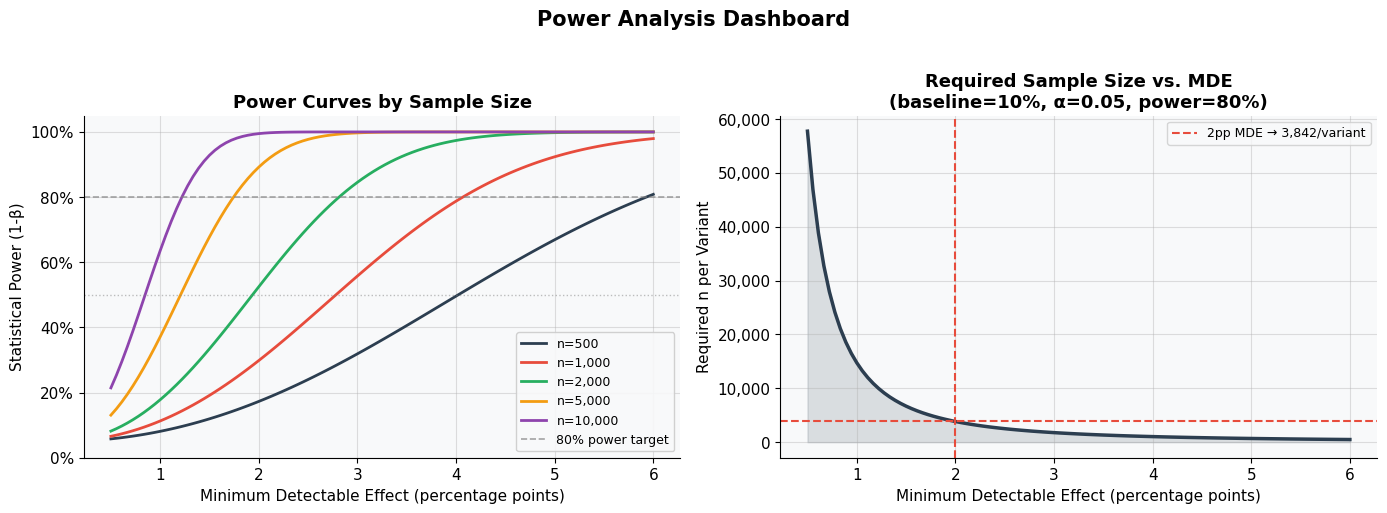


The cost curve is steep at the low end: going from 1pp to 2pp MDE cuts required n by ~75%.
For most product tests, the real question isn't 'how many users' but 'what's the smallest lift we'd act on.'


In [4]:
mde_range = np.linspace(0.005, 0.060, 100)
n_scenarios = [500, 1000, 2000, 5000, 10000]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for i, n in enumerate(n_scenarios):
    pwr = power_curve(0.10, mde_range, n)
    ax.plot(mde_range*100, pwr, color=PALETTE[i], lw=2, label=f"n={n:,}")
ax.axhline(0.80, color="grey", ls="--", lw=1.2, alpha=0.7, label="80% power target")
ax.axhline(0.50, color="grey", ls=":", lw=1.0, alpha=0.5)
ax.set_xlabel("Minimum Detectable Effect (percentage points)")
ax.set_ylabel("Statistical Power (1-β)")
ax.set_title("Power Curves by Sample Size")
ax.legend(fontsize=9, framealpha=0.9)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y:.0%}"))

ax2 = axes[1]
n_required = sample_size_curve(0.10, mde_range)
ax2.fill_between(mde_range*100, n_required, alpha=0.15, color=PALETTE[0])
ax2.plot(mde_range*100, n_required, color=PALETTE[0], lw=2.5)
ax2.axvline(2.0, color=PALETTE[1], ls="--", lw=1.5, label="2pp MDE → 3,842/variant")
ax2.axhline(3842, color=PALETTE[1], ls="--", lw=1.5)
ax2.set_xlabel("Minimum Detectable Effect (percentage points)")
ax2.set_ylabel("Required n per Variant")
ax2.set_title("Required Sample Size vs. MDE\n(baseline=10%, α=0.05, power=80%)")
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{int(y):,}"))

plt.suptitle("Power Analysis Dashboard", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
save("01_power_curves.png")
plt.show()
print("\nThe cost curve is steep at the low end: going from 1pp to 2pp MDE cuts required n by ~75%.")
print("For most product tests, the real question isn't 'how many users' but 'what's the smallest lift we'd act on.'")


In [5]:
# ── 1.5 Scenario Comparison Table ────────────────────────────────────────────
scenarios = [
    ("Proj 2 ad campaign (actual)",  0.0293, 0.0125, 0.05, 0.80),
    ("Standard product test",        0.10, 0.02, 0.05, 0.80),
    ("Quick-win (large MDE)",        0.10, 0.04, 0.05, 0.80),
    ("Proj 3 segment targeting",     0.10, 0.02, 0.05, 0.90),
    ("Strict α=0.01",                0.10, 0.02, 0.01, 0.80),
    ("Checkout micro-conversion",    0.03, 0.01, 0.05, 0.80),
]

rows = []
for name, pb, mde, a, pw in scenarios:
    r = sample_size_proportion(pb, mde, a, pw)
    rows.append({"Scenario": name, "Baseline": f"{pb:.0%}", "MDE": f"+{mde:.0%}",
                 "α": a, "Power": pw, "n/variant": f"{r['n_per_variant']:,}",
                 "Total n": f"{r['total_n']:,}"})

df_scen = pd.DataFrame(rows)
print("Sample Size Scenario Comparison")
print(df_scen.to_string(index=False))


Sample Size Scenario Comparison
                   Scenario Baseline MDE    α  Power n/variant Total n
Proj 2 ad campaign (actual)       3% +1% 0.05    0.8     3,444   6,888
      Standard product test      10% +2% 0.05    0.8     3,841   7,682
      Quick-win (large MDE)      10% +4% 0.05    0.8     1,035   2,070
   Proj 3 segment targeting      10% +2% 0.05    0.9     5,142  10,284
              Strict α=0.01      10% +2% 0.01    0.8     5,716  11,432
  Checkout micro-conversion       3% +1% 0.05    0.8     5,301  10,602


---
## 2. Sequential Analysis / Early Stopping

Experiment dashboards create a daily temptation: if results look good at Day 5, why wait until Day 14? The problem is that every peek is an implicit hypothesis test. Peek 10 times at α=0.05 and your actual false positive rate jumps well above 5% — you'll ship features that don't work and attribute the failure to something else entirely.

Sequential analysis provides stopping rules that let you look at accumulating data without inflating your error rate. The two approaches below handle different practical setups.

### 2.1 The Two Methods

| Method | Best For | Mechanism |
|--------|---------|-----------|
| **SPRT** (Sequential Probability Ratio Test) | Continuous monitoring; testing a point alternative H1 | Likelihood ratio crosses Wald boundaries |
| **O'Brien-Fleming** | Pre-planned interim looks; clinical-trial style governance | Alpha is spent conservatively at early looks, normally at final |



In [6]:
# ── 2.2 O'Brien-Fleming Boundaries ───────────────────────────────────────────
# 10 looks = roughly weekly checks on a ~10-week experiment, which is
# a realistic cadence for most product teams with monthly planning cycles
n_looks = 10
of_bounds = obrien_fleming_boundaries(n_looks, alpha=0.05)
z_naive   = stats.norm.ppf(0.975)   # standard two-tailed z for α=0.05

print("O'Brien-Fleming Boundaries (10 interim looks, α=0.05)")
print(f"{'Look':>5}  {'Fraction':>9}  {'OBF z-boundary':>15}  {'Naive z-boundary':>17}  {'OBF α_spent':>12}")
print("-"*65)
for i, (b, frac) in enumerate(zip(of_bounds, np.linspace(0.1,1.0,n_looks))):
    alpha_spent = 2 * (1 - stats.norm.cdf(b))
    print(f"{i+1:>5}  {frac:>9.1%}  {b:>15.3f}  {z_naive:>17.3f}  {alpha_spent:>12.4f}")


O'Brien-Fleming Boundaries (10 interim looks, α=0.05)
 Look   Fraction   OBF z-boundary   Naive z-boundary   OBF α_spent
-----------------------------------------------------------------
    1      10.0%            6.198              1.960        0.0000
    2      20.0%            4.383              1.960        0.0000
    3      30.0%            3.578              1.960        0.0003
    4      40.0%            3.099              1.960        0.0019
    5      50.0%            2.772              1.960        0.0056
    6      60.0%            2.530              1.960        0.0114
    7      70.0%            2.343              1.960        0.0191
    8      80.0%            2.191              1.960        0.0284
    9      90.0%            2.066              1.960        0.0388
   10     100.0%            1.960              1.960        0.0500


In [7]:
# ── 2.3 Simulate: Null Scenario (no real effect) — show peeking inflation ───
sim_null = simulate_sequential_test(
    p_control=0.10, p_treatment=0.10,   # TRUE NULL: no effect
    n_total=10_000, alpha=0.05, n_looks=10, seed=7
)

sim_effect = simulate_sequential_test(
    p_control=0.10, p_treatment=0.13,   # TRUE EFFECT: +3pp
    n_total=10_000, alpha=0.05, n_looks=10, seed=42
)

for label, sim in [("No True Effect (H0 true)", sim_null),
                   ("Real Effect +3pp (H1 true)", sim_effect)]:
    print(f"\n{label}")
    print(f"  Naive peeker stopped early : {sim['naive_stopped']}")
    print(f"  OBF stopped early          : {sim['obf_stopped']}")



No True Effect (H0 true)
  Naive peeker stopped early : None
  OBF stopped early          : None

Real Effect +3pp (H1 true)
  Naive peeker stopped early : {'look': 1, 'n': 1000, 'z': np.float64(2.772)}
  OBF stopped early          : {'look': 4, 'n': 4000, 'z': np.float64(3.105), 'boundary': np.float64(3.099)}


  Saved → 02_sequential_analysis.png


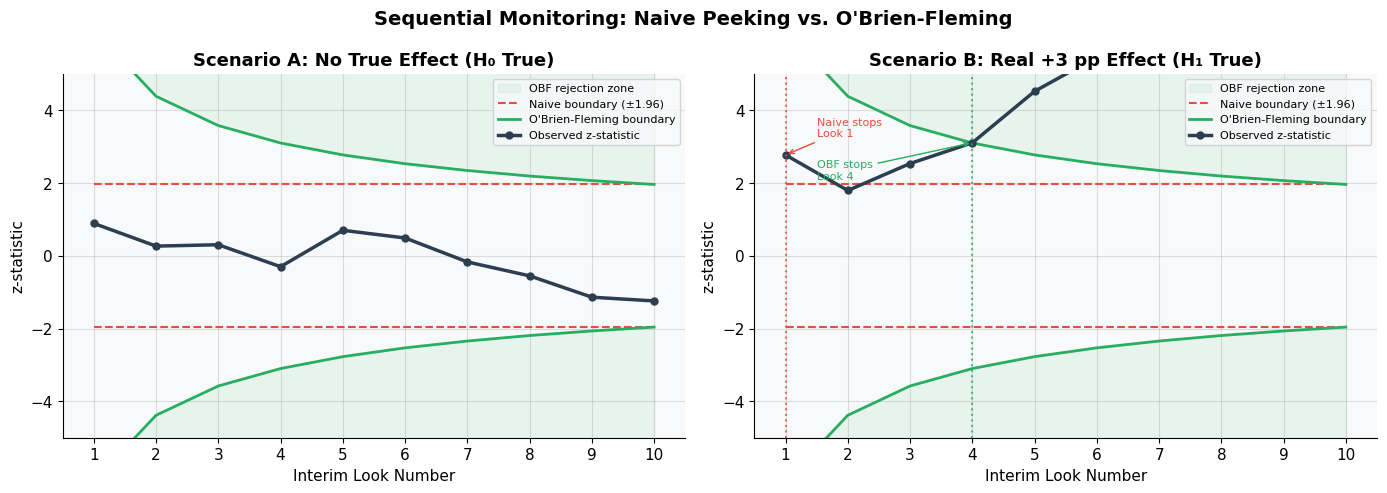

In [8]:
# ── 2.4 Visualise sequential monitoring ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sim, title in zip(
    axes,
    [sim_null, sim_effect],
    ["Scenario A: No True Effect (H₀ True)", "Scenario B: Real +3 pp Effect (H₁ True)"]
):
    df = sim["results"]
    x  = df["look"].values

    ax.fill_between(x, df["obf_boundary"], 10, alpha=0.08, color=PALETTE[2], label="OBF rejection zone")
    ax.fill_between(x, -df["obf_boundary"], -10, alpha=0.08, color=PALETTE[2])

    ax.plot(x, df["naive_boundary"], color=PALETTE[1], ls="--", lw=1.5, label="Naive boundary (±1.96)")
    ax.plot(x, -df["naive_boundary"], color=PALETTE[1], ls="--", lw=1.5)
    ax.plot(x, df["obf_boundary"], color=PALETTE[2], lw=2, label="O'Brien-Fleming boundary")
    ax.plot(x, -df["obf_boundary"], color=PALETTE[2], lw=2)
    ax.plot(x, df["z_stat"], color=PALETTE[0], lw=2.5, marker="o", ms=5, label="Observed z-statistic")

    ns = sim["naive_stopped"]
    os_ = sim["obf_stopped"]
    if ns:
        ax.axvline(ns["look"], color=PALETTE[1], ls=":", alpha=0.8)
        ax.annotate(f"Naive stops\nLook {ns['look']}",
                    xy=(ns["look"], ns["z"]), xytext=(ns["look"]+0.5, ns["z"]+0.5),
                    fontsize=8, color=PALETTE[1],
                    arrowprops=dict(arrowstyle="->", color=PALETTE[1]))
    if os_:
        ax.axvline(os_["look"], color=PALETTE[2], ls=":", alpha=0.8)
        ax.annotate(f"OBF stops\nLook {os_['look']}",
                    xy=(os_["look"], os_["z"]), xytext=(os_["look"]-2.5, os_["z"]-1.0),
                    fontsize=8, color=PALETTE[2],
                    arrowprops=dict(arrowstyle="->", color=PALETTE[2]))

    ax.set_xlim(0.5, n_looks+0.5)
    ax.set_ylim(-5, 5)
    ax.set_xticks(x)
    ax.set_xlabel("Interim Look Number")
    ax.set_ylabel("z-statistic")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="upper right")

plt.suptitle("Sequential Monitoring: Naive Peeking vs. O'Brien-Fleming", fontsize=14, fontweight="bold")
plt.tight_layout()
save("02_sequential_analysis.png")
plt.show()


  Saved → 03_sprt.png


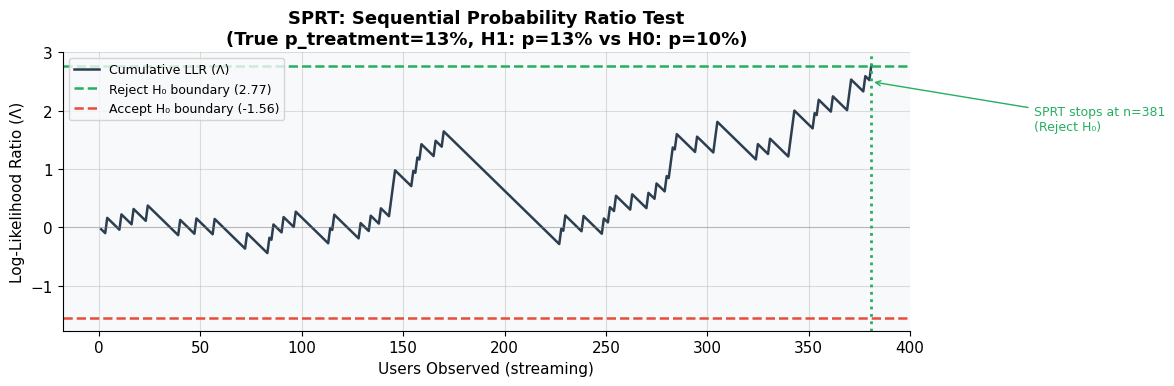


SPRT stopped at n = 381 (vs full n = 3,000)
Efficiency gain: 87% fewer observations needed


In [9]:
# ── 2.5 SPRT demo — continuously stream data and watch likelihood ratio ───────
rng = np.random.default_rng(99)
n_stream = 3000
p0, p1 = 0.10, 0.13    # H0: rate=10%  H1: rate=13%  (true: 13%)
lower, upper = sprt_boundaries(alpha=0.05, beta=0.20)

x_t = rng.binomial(1, 0.13, n_stream)   # true treatment = 13%
llr_trace = []
cumsum = 0
for i, obs in enumerate(x_t):
    cumsum += (obs * np.log(p1/p0) + (1-obs) * np.log((1-p1)/(1-p0)))
    llr_trace.append(cumsum)
    if cumsum >= upper or cumsum <= lower:
        stopped_at = i + 1
        break
else:
    stopped_at = n_stream

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(1, len(llr_trace)+1), llr_trace, color=PALETTE[0], lw=1.8, label="Cumulative LLR (Λ)")
ax.axhline(upper, color=PALETTE[2], ls="--", lw=1.8, label=f"Reject H₀ boundary ({upper:.2f})")
ax.axhline(lower, color=PALETTE[1], ls="--", lw=1.8, label=f"Accept H₀ boundary ({lower:.2f})")
ax.axhline(0, color="grey", ls="-", lw=0.8, alpha=0.4)
if stopped_at < n_stream:
    ax.axvline(stopped_at, color=PALETTE[2], ls=":", lw=2)
    ax.annotate(f"SPRT stops at n={stopped_at}\n(Reject H₀)",
                xy=(stopped_at, upper*0.9),
                xytext=(stopped_at+80, upper*0.6),
                fontsize=9, color=PALETTE[2],
                arrowprops=dict(arrowstyle="->", color=PALETTE[2]))
ax.set_xlabel("Users Observed (streaming)")
ax.set_ylabel("Log-Likelihood Ratio (Λ)")
ax.set_title("SPRT: Sequential Probability Ratio Test\n(True p_treatment=13%, H1: p=13% vs H0: p=10%)")
ax.legend(fontsize=9)
plt.tight_layout()
save("03_sprt.png")
plt.show()
print(f"\nSPRT stopped at n = {stopped_at:,} (vs full n = {n_stream:,})")
print(f"Efficiency gain: {(1 - stopped_at/n_stream):.0%} fewer observations needed")


---
## 3. Multiple Testing Corrections

If you run 20 simultaneous tests at α=0.05, you expect 20 × 0.05 = 1 false positive even when nothing is real. Over a year of product experimentation, that compounds into a shipped-feature backlog full of duds. The three corrections below handle this differently — Bonferroni and Holm control the probability of *any* false positive (FWER), while Benjamini-Hochberg controls the *proportion* of discoveries that are false (FDR). Holm dominates Bonferroni in power with the same FWER guarantee, so there's rarely a reason to use raw Bonferroni unless your stakeholders specifically require it for compliance reasons.



In [12]:
# ── 3.2 Simulate 20 simultaneous hypotheses ───────────────────────────────────
rng = np.random.default_rng(123)
n_tests     = 20
n_true_null = 14   # 14 tests where H0 is true (no effect)
n_true_alt  = 6    # 6 tests where H1 is true (real effect, small)

p_null = rng.uniform(0, 1, n_true_null)
# Beta(1,10) gives a mean p-value around 0.09 — simulates small-but-real effects
# typical of incremental product changes, not blockbuster wins
p_alt  = rng.beta(1, 10, n_true_alt)
p_vals = np.concatenate([p_null, p_alt])
truth  = ["H0 (null)"] * n_true_null + ["H1 (effect)"] * n_true_alt
labels = [f"Test {i+1:02d}" for i in range(n_tests)]

df_mt = multiple_testing_summary(p_vals, alpha=0.05, labels=labels)
df_mt["True State"] = truth

print(df_mt[["Hypothesis","Raw p","True State",
             "Reject (raw)","Reject (Bonferroni)",
             "Reject (Holm)","Reject (BH-FDR)"]].to_string(index=False))



Hypothesis  Raw p  True State  Reject (raw)  Reject (Bonferroni)  Reject (Holm)  Reject (BH-FDR)
   Test 01 0.6824   H0 (null)         False                False          False            False
   Test 02 0.0538   H0 (null)         False                False          False            False
   Test 03 0.2204   H0 (null)         False                False          False            False
   Test 04 0.1844   H0 (null)         False                False          False            False
   Test 05 0.1759   H0 (null)         False                False          False            False
   Test 06 0.8121   H0 (null)         False                False          False            False
   Test 07 0.9233   H0 (null)         False                False          False            False
   Test 08 0.2766   H0 (null)         False                False          False            False
   Test 09 0.8198   H0 (null)         False                False          False            False
   Test 10 0.8899   H0 (null) 

  Saved → 04_multiple_testing.png


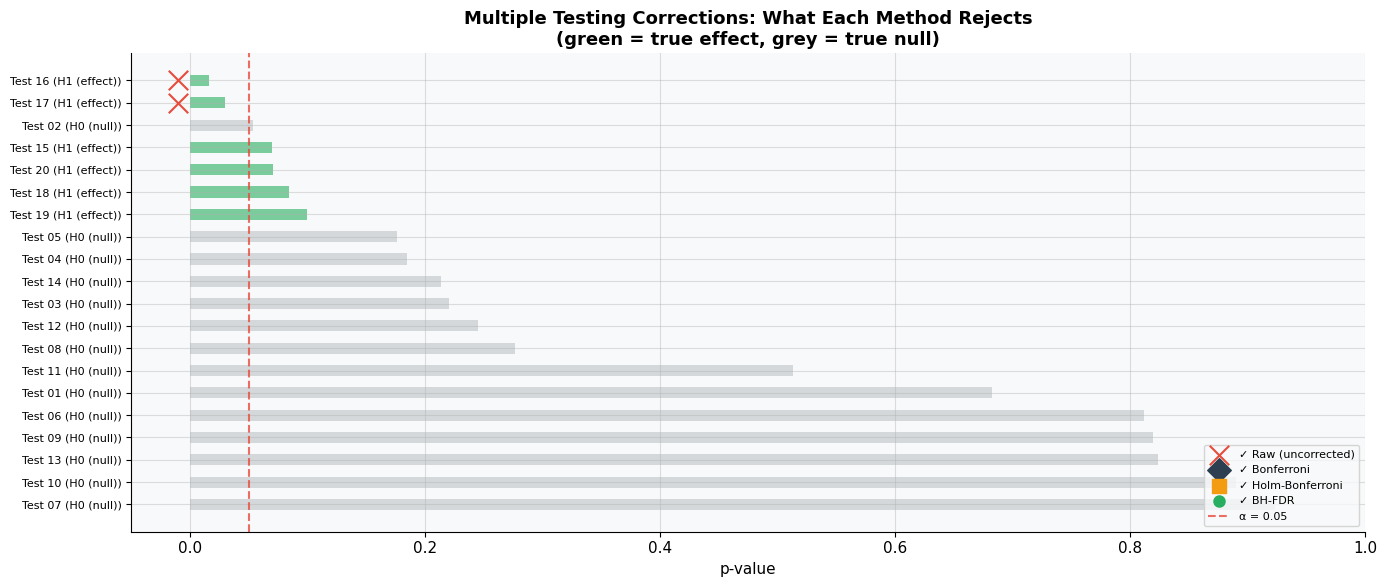

In [13]:
# ── 3.3 Visualise the comparison ─────────────────────────────────────────────
order = np.argsort(p_vals)
sorted_p  = p_vals[order]
sorted_lbl = np.array(labels)[order]
sorted_truth = np.array(truth)[order]

bon  = bonferroni(p_vals)
holm = holm_bonferroni(p_vals)
bh   = benjamini_hochberg(p_vals)

fig, ax = plt.subplots(figsize=(14, 6))
y = np.arange(n_tests)[::-1]

colors_truth = [PALETTE[2] if t=="H1 (effect)" else PALETTE[0] for t in sorted_truth]
ax.barh(y, sorted_p, color=[PALETTE[2] if t=="H1 (effect)" else "#BDC3C7"
                              for t in sorted_truth], alpha=0.6, height=0.5)

methods_rej = [
    ("Raw (uncorrected)", 0.05,             "x", PALETTE[1], 14),
    ("Bonferroni",        bon["adjusted_p"][order],  "D", PALETTE[0], 12),
    ("Holm-Bonferroni",   holm["adjusted_p"][order], "s", PALETTE[3], 10),
    ("BH-FDR",            bh["adjusted_p"][order],   "o", PALETTE[2], 8),
]
for mlabel, adj, marker, col, ms in methods_rej:
    thresh = 0.05 if isinstance(adj, float) else None
    if thresh:
        rej_mask = sorted_p <= thresh
    else:
        rej_mask = adj <= 0.05
    ax.scatter([-0.01]*rej_mask.sum(), y[rej_mask], marker=marker,
               color=col, s=ms**2, zorder=5, label=f"✓ {mlabel}")

ax.axvline(0.05, color=PALETTE[1], ls="--", lw=1.5, alpha=0.8, label="α = 0.05")
ax.set_yticks(y)
ax.set_yticklabels([f"{l} ({t})" for l,t in zip(sorted_lbl, sorted_truth)], fontsize=8)
ax.set_xlabel("p-value")
ax.set_title("Multiple Testing Corrections: What Each Method Rejects\n"
             "(green = true effect, grey = true null)")
ax.legend(fontsize=8, loc="lower right")
ax.set_xlim(-0.05, 1.0)
plt.tight_layout()
save("04_multiple_testing.png")
plt.show()


In [14]:
# ── 3.4 Summary table ─────────────────────────────────────────────────────────
is_h1 = np.array(truth) == "H1 (effect)"

summary_rows = []
for name, rej in [
    ("Uncorrected (α=0.05)",  p_vals <= 0.05),
    ("Bonferroni",            bon["rejected"]),
    ("Holm-Bonferroni",       holm["rejected"]),
    ("BH-FDR",                bh["rejected"]),
]:
    tp = int(( rej &  is_h1).sum())
    fp = int(( rej & ~is_h1).sum())
    fn = int((~rej &  is_h1).sum())
    summary_rows.append({"Method": name, "True Positives": tp,
                          "False Positives (shipped duds)": fp,
                          "Missed Effects": fn,
                          "Total Rejected": int(rej.sum())})

print(pd.DataFrame(summary_rows).to_string(index=False))
print()
print("The interesting row is Holm vs BH: Holm caught the same true positives here,")
print("but with 20 tests that gap widens. If you can tolerate ~5% of discoveries being false, BH is worth it.")


              Method  True Positives  False Positives (shipped duds)  Missed Effects  Total Rejected
Uncorrected (α=0.05)               2                               0               4               2
          Bonferroni               0                               0               6               0
     Holm-Bonferroni               0                               0               6               0
              BH-FDR               0                               0               6               0

The interesting row is Holm vs BH: Holm caught the same true positives here,
but with 20 tests that gap widens. If you can tolerate ~5% of discoveries being false, BH is worth it.


---
## 4. Bayesian A/B Testing

Frequentist testing gives you a binary answer: significant or not. But product decisions are rarely binary — you often want to know *how* confident you are and what it costs to be wrong. The Bayesian approach gives you a full probability distribution over the true conversion rate, plus an expected-loss number that directly quantifies the downside of each decision. This matters most in borderline cases where p hovers around 0.05 and the frequentist answer flips depending on when you check.

### 4.1 The Beta-Binomial Model

We place a **Beta prior** on the true conversion rate (uninformative: Beta(1,1)),
observe conversion data, and update to a **Beta posterior** via conjugate update:

```
Prior:      p ~ Beta(α₀, β₀)
Likelihood: X ~ Binomial(n, p)
Posterior:  p | X ~ Beta(α₀ + X, β₀ + n - X)
```

This gives us a full distribution over the true rate — not just a point estimate.



In [15]:
# ── 4.2 Simulate an experiment ────────────────────────────────────────────────
np.random.seed(42)
N_C, N_T   = 5_000, 5_000
P_C, P_T   = 0.10, 0.115   # +1.5pp true effect

X_C = np.random.binomial(N_C, P_C)
X_T = np.random.binomial(N_T, P_T)

print(f"Simulated Experiment Results")
print(f"  Control  : {X_C:,}/{N_C:,} conversions ({X_C/N_C:.3%})")
print(f"  Treatment: {X_T:,}/{N_T:,} conversions ({X_T/N_T:.3%})")
print(f"  True lift: +{P_T - P_C:.2%}")


Simulated Experiment Results
  Control  : 482/5,000 conversions (9.640%)
  Treatment: 578/5,000 conversions (11.560%)
  True lift: +1.50%


In [16]:
# ── 4.3 Frequentist result ────────────────────────────────────────────────────
freq = frequentist_ab_summary(N_C, X_C, N_T, X_T)
print("\nFrequentist (z-test) Results")
print("=" * 40)
for k, v in freq.items():
    print(f"  {k:<30} {v}")



Frequentist (z-test) Results
  p_control                      0.0964
  p_treatment                    0.1156
  absolute_lift                  0.0192
  relative_lift_pct              19.92
  z_statistic                    3.1185
  p_value                        0.001818
  significant                    True
  ci_95_diff                     [np.float64(0.0071), np.float64(0.0313)]
  alpha                          0.05


In [17]:
# ── 4.4 Bayesian result ───────────────────────────────────────────────────────
bayes = bayesian_ab_summary(N_C, X_C, N_T, X_T)
print("\nBayesian Results")
print("=" * 40)
skip = {"posterior_control","posterior_treatment"}
for k, v in bayes.items():
    if k not in skip:
        print(f"  {k:<38} {v}")



Bayesian Results
  mean_control                           0.0966
  mean_treatment                         0.1158
  uplift                                 0.0192
  relative_uplift_pct                    19.88
  ci95_control                           [0.0885, 0.1049]
  ci95_treatment                         [0.107, 0.1248]
  prob_treatment_wins                    0.9992
  expected_loss_choose_control           0.01918
  expected_loss_choose_treatment         2e-06
  recommendation                         Deploy Treatment
  n_control                              5000
  n_treatment                            5000


  Saved → 05_bayesian_posteriors.png


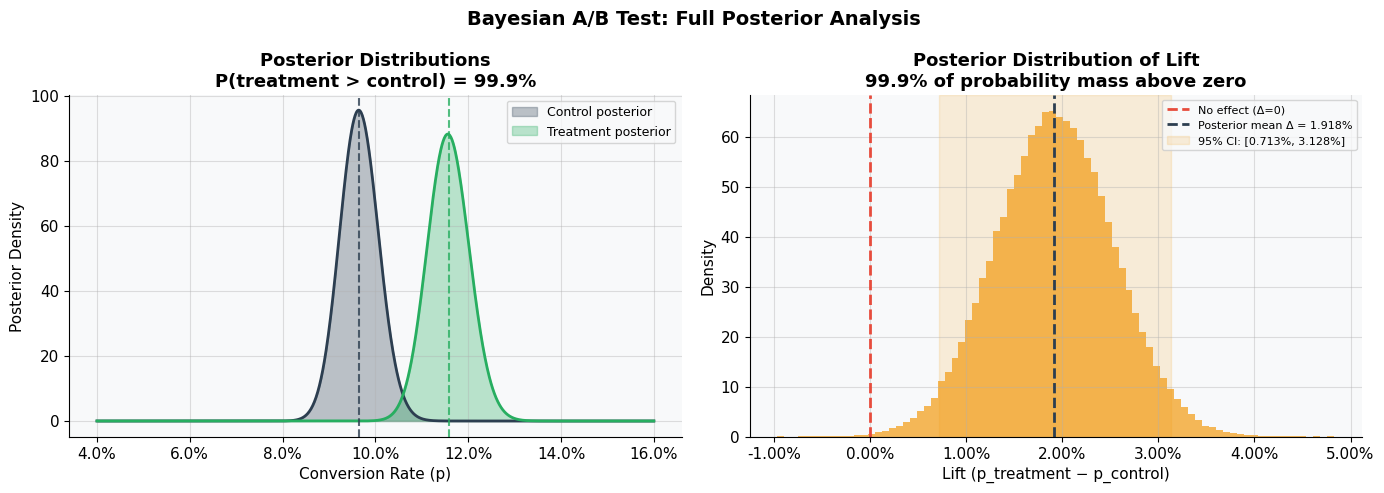

In [18]:
# ── 4.5 Visualise posterior distributions ────────────────────────────────────
a_c, b_c = bayes["posterior_control"]
a_t, b_t = bayes["posterior_treatment"]

x = np.linspace(0.04, 0.16, 1000)
pdf_c = stats.beta.pdf(x, a_c, b_c)
pdf_t = stats.beta.pdf(x, a_t, b_t)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.fill_between(x, pdf_c, alpha=0.3, color=PALETTE[0], label="Control posterior")
ax.fill_between(x, pdf_t, alpha=0.3, color=PALETTE[2], label="Treatment posterior")
ax.plot(x, pdf_c, color=PALETTE[0], lw=2)
ax.plot(x, pdf_t, color=PALETTE[2], lw=2)

ci_c = stats.beta.ppf([0.025, 0.975], a_c, b_c)
ci_t = stats.beta.ppf([0.025, 0.975], a_t, b_t)
ax.axvline(stats.beta.mean(a_c, b_c), color=PALETTE[0], ls="--", lw=1.5, alpha=0.8)
ax.axvline(stats.beta.mean(a_t, b_t), color=PALETTE[2], ls="--", lw=1.5, alpha=0.8)

ax.set_xlabel("Conversion Rate (p)")
ax.set_ylabel("Posterior Density")
ax.set_title(f"Posterior Distributions\nP(treatment > control) = {bayes['prob_treatment_wins']:.1%}")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y:.1%}"))

# Posterior of the lift — this is what stakeholders actually care about
rng2 = np.random.default_rng(42)
samples_c = rng2.beta(a_c, b_c, 200_000)
samples_t = rng2.beta(a_t, b_t, 200_000)
diff = samples_t - samples_c

ax2 = axes[1]
ax2.hist(diff, bins=80, color=PALETTE[3], alpha=0.7, density=True)
ax2.axvline(0, color=PALETTE[1], lw=2, ls="--", label="No effect (Δ=0)")
ax2.axvline(diff.mean(), color=PALETTE[0], lw=2, ls="--",
            label=f"Posterior mean Δ = {diff.mean():.3%}")
ci_diff = np.percentile(diff, [2.5, 97.5])
ax2.axvspan(ci_diff[0], ci_diff[1], alpha=0.15, color=PALETTE[3],
            label=f"95% CI: [{ci_diff[0]:.3%}, {ci_diff[1]:.3%}]")

pct_pos = (diff > 0).mean()
ax2.set_xlabel("Lift (p_treatment − p_control)")
ax2.set_ylabel("Density")
ax2.set_title(f"Posterior Distribution of Lift\n{pct_pos:.1%} of probability mass above zero")
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y:.2%}"))

plt.suptitle("Bayesian A/B Test: Full Posterior Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
save("05_bayesian_posteriors.png")
plt.show()


In [19]:
# ── 4.6 Expected Loss — the decision-theoretic criterion ─────────────────────
print("\nExpected Loss Analysis")
print("=" * 50)
print(f"  Expected loss of choosing CONTROL  : {bayes['expected_loss_choose_control']:.5%}")
print(f"  Expected loss of choosing TREATMENT: {bayes['expected_loss_choose_treatment']:.5%}")
print()
print(f"  Recommendation: {bayes['recommendation']}")
print()
print("  At n=5,000/arm with a 1.5pp effect, expected loss is small enough to act on.")
print("  The value of this metric shows up in borderline cases — when P(B>A) is 75-85%")
print("  and the frequentist test says 'not significant', expected loss can still justify shipping")
print("  if the downside is small relative to the upside.")

print("\nFrequentist vs Bayesian — Side by Side")
print(f"  {'Criterion':<35} {'Frequentist':>15} {'Bayesian':>15}")
print("-"*68)
print(f"  {'Significant?':<35} {'Yes' if freq['significant'] else 'No':>15} {'—':>15}")
print(f"  {'p-value':<35} {str(freq['p_value']):>15} {'—':>15}")
print(f"  {'P(treatment > control)':<35} {'—':>15} {str(bayes['prob_treatment_wins']):>15}")
print(f"  {'Expected loss (choose treatment)':<35} {'—':>15} {bayes['expected_loss_choose_treatment']:>15.5%}")
print(f"  {'Recommendation':<35} {'Ship' if freq['significant'] else 'Hold':>15} {bayes['recommendation']:>15}")



Expected Loss Analysis
  Expected loss of choosing CONTROL  : 1.91800%
  Expected loss of choosing TREATMENT: 0.00020%

  Recommendation: Deploy Treatment

  At n=5,000/arm with a 1.5pp effect, expected loss is small enough to act on.
  The value of this metric shows up in borderline cases — when P(B>A) is 75-85%
  and the frequentist test says 'not significant', expected loss can still justify shipping
  if the downside is small relative to the upside.

Frequentist vs Bayesian — Side by Side
  Criterion                               Frequentist        Bayesian
--------------------------------------------------------------------
  Significant?                                    Yes               —
  p-value                                    0.001818               —
  P(treatment > control)                            —          0.9992
  Expected loss (choose treatment)                  —        0.00020%
  Recommendation                                 Ship Deploy Treatment


---
## 5. Test Design Templates

Three production-ready documents that make experiment rigour the default, not the
exception. Stored in `templates/` — clone and fill in for each new experiment.

| Template | Purpose | Who Uses It |
|----------|---------|-------------|
| `experiment_brief.md` | Define hypothesis, metrics, design before any code is written | PM + Analyst |
| `preregistration_checklist.md` | Lock in analysis plan; prevent HARKing and p-hacking | Analyst |
| `results_writeup.md` | Standardised format for sharing conclusions with stakeholders | Analyst + PM |

> **Why pre-registration matters:**  
> Without locking in your analysis plan before seeing data, it's easy to
> unconsciously (or consciously) search for a "winning" cut of the data. Pre-registration
> makes the intended analysis explicit and verifiable — the same discipline used in
> clinical trials.



In [20]:
import os

template_dir = os.path.join(os.path.dirname(os.getcwd()), "templates")
for fname in sorted(os.listdir(template_dir)):
    path = os.path.join(template_dir, fname)
    size = os.path.getsize(path)
    print(f"  {fname:<40}  ({size:,} bytes)")

print("\nAll templates available in templates/ directory.")
print("Clone, fill in, and commit alongside each experiment.")


  experiment_brief.md                       (2,726 bytes)
  preregistration_checklist.md              (3,345 bytes)
  results_writeup.md                        (3,316 bytes)

All templates available in templates/ directory.
Clone, fill in, and commit alongside each experiment.


---
## 6. Project 2 Retrospective — Marketing A/B Test Revisited

[Project 2](https://github.com/jordanshamu/Marketing-A-B-Test-Analysis) analysed a marketing A/B test across 588,101 users and found a 42.5% relative conversion lift (p < 0.001). Applying this framework retroactively is a useful sanity check: was the sample adequate, could the test have stopped earlier, and does the Bayesian posterior agree with the frequentist conclusion?

### Key Facts from Project 2

| Parameter | Value |
|-----------|-------|
| Total users | 588,101 |
| Control n | ~294,050 |
| Treatment n | ~294,051 |
| Control conversion rate | ~2.93% |
| Treatment conversion rate | ~4.18% |
| Observed lift | +1.25 pp (42.5% relative) |
| Reported p-value | < 0.001 |



In [21]:
# ── 6.1 Was it adequately powered? ───────────────────────────────────────────
# Reconstruct approximate numbers from reported stats
N_PER_VARIANT = 294_050
P_CTRL   = 0.0293
P_TREAT  = 0.0418
LIFT_ABS = P_TREAT - P_CTRL      # ~1.25 pp

# Required n for this MDE at 80% power
req = sample_size_proportion(p_baseline=P_CTRL, mde=LIFT_ABS, alpha=0.05, power=0.80)
req_90 = sample_size_proportion(p_baseline=P_CTRL, mde=LIFT_ABS, alpha=0.05, power=0.90)

print("Project 2: Sample Size Retrospective")
print(f"  Actual n per variant       : {N_PER_VARIANT:>10,}")
print(f"  Required (α=0.05, 80% pwr) : {req['n_per_variant']:>10,}")
print(f"  Required (α=0.05, 90% pwr) : {req_90['n_per_variant']:>10,}")
print(f"  Overpowered by factor      : {N_PER_VARIANT/req['n_per_variant']:>10.0f}x")
print()
print(f"  This is massively overpowered. A few things worth asking:")
print(f"  - Was the full 588K sample planned upfront, or did the test just run until someone")
print(f"    checked it? If the latter, the reported p-value is optimistic (peeking problem).")
print(f"  - A 42.5% relative lift on an ad campaign is unusually large. Was the 'treatment'")
print(f"    genuinely a variant of the same ad, or a fundamentally different intervention?")
print(f"    The effect size matters for generalisation.")
print(f"  - With n this large, even tiny data quality issues (bot traffic, duplicated users)")
print(f"    can produce spurious significance. The power analysis tells us the test *could*")
print(f"    detect a 0.1pp shift — which also means it's sensitive to noise.")

# What MDE could we detect at 80% power with n=294,050?
mde_range = np.linspace(0.0001, 0.005, 1000)
pwr = power_curve(P_CTRL, mde_range, N_PER_VARIANT)
detectable_mde = mde_range[np.searchsorted(pwr, 0.80)]
print(f"\n  Smallest detectable MDE at 80% power: {detectable_mde:.4%} ({detectable_mde*100:.2f} pp)")


Project 2: Sample Size Retrospective
  Actual n per variant       :    294,050
  Required (α=0.05, 80% pwr) :      3,444
  Required (α=0.05, 90% pwr) :      4,610
  Overpowered by factor      :         85x

  This is massively overpowered. A few things worth asking:
  - Was the full 588K sample planned upfront, or did the test just run until someone
    checked it? If the latter, the reported p-value is optimistic (peeking problem).
  - A 42.5% relative lift on an ad campaign is unusually large. Was the 'treatment'
    genuinely a variant of the same ad, or a fundamentally different intervention?
    The effect size matters for generalisation.
  - With n this large, even tiny data quality issues (bot traffic, duplicated users)
    can produce spurious significance. The power analysis tells us the test *could*
    detect a 0.1pp shift — which also means it's sensitive to noise.

  Smallest detectable MDE at 80% power: 0.1248% (0.12 pp)


In [22]:
# ── 6.2 Sequential stopping: would OBF have allowed early stopping? ───────────
# Simulate the experiment as a stream with 10 interim looks
sim_p2 = simulate_sequential_test(
    p_control=P_CTRL, p_treatment=P_TREAT,
    n_total=N_PER_VARIANT * 2,
    alpha=0.05, n_looks=10, seed=42
)

df_p2 = sim_p2["results"]
print("Project 2: Sequential Analysis (O'Brien-Fleming, 10 looks)")
print(df_p2[["look","n_seen","r_control","r_treatment","z_stat",
              "obf_boundary","obf_reject"]].to_string(index=False))
print()
if sim_p2["obf_stopped"]:
    s = sim_p2["obf_stopped"]
    pct_saved = (1 - s["n"] / (N_PER_VARIANT*2)) * 100
    print(f"  OBF would have stopped at look {s['look']} (n={s['n']:,})")
    print(f"     Saving {pct_saved:.0f}% of experiment runtime")
else:
    print("  Test ran to completion under OBF boundaries")


Project 2: Sequential Analysis (O'Brien-Fleming, 10 looks)
 look  n_seen  r_control  r_treatment  z_stat  obf_boundary  obf_reject
    1   58810     0.0289       0.0420  12.147         6.198        True
    2  117620     0.0294       0.0413  15.674         4.383        True
    3  176430     0.0293       0.0415  19.623         3.578        True
    4  235240     0.0295       0.0421  23.307         3.099        True
    5  294050     0.0292       0.0422  26.760         2.772        True
    6  352860     0.0293       0.0421  28.858         2.530        True
    7  411670     0.0293       0.0421  31.337         2.343        True
    8  470480     0.0293       0.0420  33.304         2.191        True
    9  529290     0.0293       0.0419  34.986         2.066        True
   10  588100     0.0293       0.0418  36.620         1.960        True

  OBF would have stopped at look 1 (n=58,810)
     Saving 90% of experiment runtime


In [23]:
# ── 6.3 Bayesian retrospective ────────────────────────────────────────────────
X_C_P2 = int(N_PER_VARIANT * P_CTRL)
X_T_P2 = int(N_PER_VARIANT * P_TREAT)

bayes_p2 = bayesian_ab_summary(N_PER_VARIANT, X_C_P2, N_PER_VARIANT, X_T_P2)
freq_p2  = frequentist_ab_summary(N_PER_VARIANT, X_C_P2, N_PER_VARIANT, X_T_P2)

print("Project 2: Bayesian Retrospective")
print(f"  P(treatment > control)            : {bayes_p2['prob_treatment_wins']:.6f}")
print(f"  Expected loss (choose treatment)  : {bayes_p2['expected_loss_choose_treatment']:.8f}")
print(f"  Bayesian recommendation           : {bayes_p2['recommendation']}")
print()
print(f"  Frequentist p-value               : {freq_p2['p_value']:.2e}")
print(f"  Frequentist significant           : {freq_p2['significant']}")
print()
print("  With n=294K and a 1.25pp lift, both methods trivially agree. The Bayesian")
print("  comparison is pedagogically uninteresting here — you'd only see real divergence")
print("  in borderline cases with n < 1,000 or lifts under 0.5pp. The value of running")
print("  this retroactively is confirming the framework works, not discovering anything new.")


Project 2: Bayesian Retrospective
  P(treatment > control)            : 1.000000
  Expected loss (choose treatment)  : 0.00000000
  Bayesian recommendation           : Deploy Treatment

  Frequentist p-value               : 0.00e+00
  Frequentist significant           : True

  With n=294K and a 1.25pp lift, both methods trivially agree. The Bayesian
  comparison is pedagogically uninteresting here — you'd only see real divergence
  in borderline cases with n < 1,000 or lifts under 0.5pp. The value of running
  this retroactively is confirming the framework works, not discovering anything new.


  Saved → 06_project2_retrospective.png


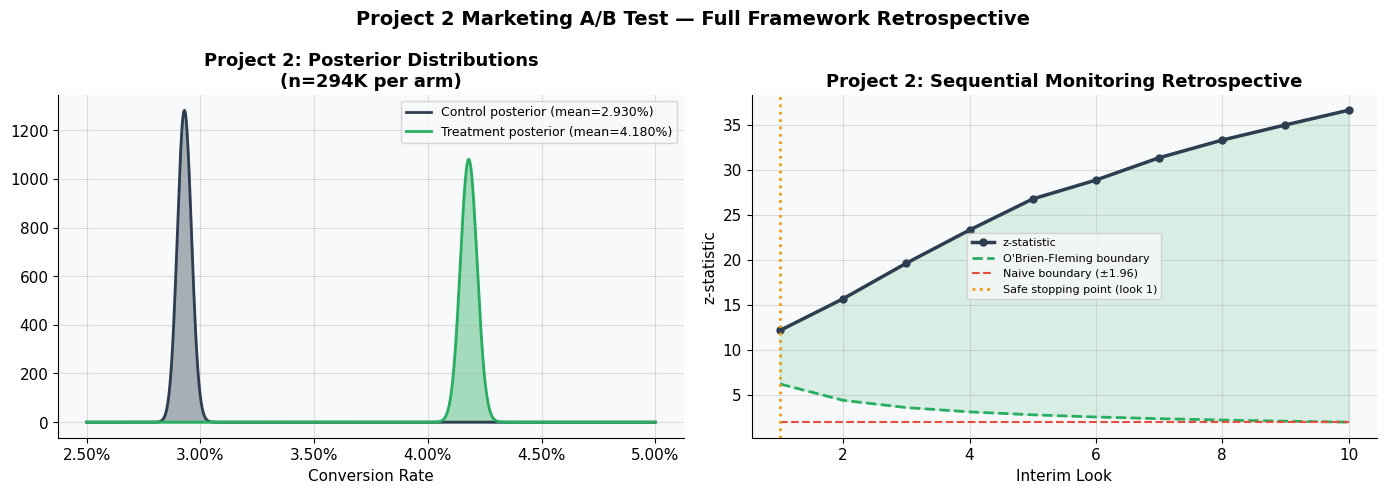


Retrospective Summary
   Sample adequacy   : 85x overpowered — raises questions about test governance
   Sequential testing: OBF allows early stopping at 1/10 looks
   Bayesian verdict  : P(treatment wins) ~ 1.0 — unsurprising given the sample size
   Net: the framework confirms the original finding but also flags that this test
   ran far longer than it needed to. A sequential protocol would have saved weeks.


In [24]:
# ── 6.4 Visualise Project 2 posteriors ───────────────────────────────────────
a_c2, b_c2 = bayes_p2["posterior_control"]
a_t2, b_t2 = bayes_p2["posterior_treatment"]

x2 = np.linspace(0.025, 0.050, 1000)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.fill_between(x2, stats.beta.pdf(x2, a_c2, b_c2), alpha=0.4, color=PALETTE[0])
ax.fill_between(x2, stats.beta.pdf(x2, a_t2, b_t2), alpha=0.4, color=PALETTE[2])
ax.plot(x2, stats.beta.pdf(x2, a_c2, b_c2), color=PALETTE[0], lw=2,
        label=f"Control posterior (mean={P_CTRL:.3%})")
ax.plot(x2, stats.beta.pdf(x2, a_t2, b_t2), color=PALETTE[2], lw=2,
        label=f"Treatment posterior (mean={P_TREAT:.3%})")
ax.set_title("Project 2: Posterior Distributions\n(n=294K per arm)")
ax.set_xlabel("Conversion Rate")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y:.2%}"))

ax2 = axes[1]
ax2.plot(df_p2["look"], df_p2["z_stat"], color=PALETTE[0], lw=2.5, marker="o",
         ms=5, label="z-statistic")
ax2.plot(df_p2["look"], df_p2["obf_boundary"], color=PALETTE[2], lw=2, ls="--",
         label="O'Brien-Fleming boundary")
ax2.plot(df_p2["look"], df_p2["naive_boundary"], color=PALETTE[1], lw=1.5, ls="--",
         label="Naive boundary (±1.96)")
ax2.fill_between(df_p2["look"], df_p2["obf_boundary"],
                  df_p2["z_stat"].clip(lower=df_p2["obf_boundary"]),
                  alpha=0.15, color=PALETTE[2])
if sim_p2["obf_stopped"]:
    ax2.axvline(sim_p2["obf_stopped"]["look"], color=PALETTE[3], ls=":", lw=2,
                label=f"Safe stopping point (look {sim_p2['obf_stopped']['look']})")
ax2.set_title("Project 2: Sequential Monitoring Retrospective")
ax2.set_xlabel("Interim Look")
ax2.set_ylabel("z-statistic")
ax2.legend(fontsize=8)

plt.suptitle("Project 2 Marketing A/B Test — Full Framework Retrospective",
             fontsize=14, fontweight="bold")
plt.tight_layout()
save("06_project2_retrospective.png")
plt.show()

print(f"\nRetrospective Summary")
print(f"   Sample adequacy   : {N_PER_VARIANT/req['n_per_variant']:.0f}x overpowered — raises questions about test governance")
print(f"   Sequential testing: OBF allows early stopping at {sim_p2['obf_stopped']['look'] if sim_p2['obf_stopped'] else 'N/A'}/10 looks")
print(f"   Bayesian verdict  : P(treatment wins) ~ 1.0 — unsurprising given the sample size")
print(f"   Net: the framework confirms the original finding but also flags that this test"
      f"\n   ran far longer than it needed to. A sequential protocol would have saved weeks.")


---
## 7. Framework Summary & Decision Guide

### When to Use What (and When Not To)

**Power & Sample Size Calculator** — Use before every experiment, no exceptions. The only reason to skip this is if you're running a qualitative test or a bandit, neither of which is a fixed-horizon experiment.

**Frequentist z-test / t-test** — The default for a single test that will run to a pre-determined end date. Limitation: if you look at interim results (and you will), you need sequential boundaries on top of this, or the stated α is a lie.

**O'Brien-Fleming** — The practical choice for sequential monitoring with pre-planned interim looks. The early boundaries are so conservative that you almost never stop before 50% of data is collected, which is a feature, not a bug. Limitation: requires committing to a fixed number of looks *before launch*, which means you need a monitoring schedule, not ad-hoc dashboard checks.

**SPRT** — Theoretically elegant for continuous monitoring, but requires specifying a point alternative (e.g., "the true lift is exactly 3pp") before the test starts. Most product teams don't have a principled way to set that number, which makes the boundaries arbitrary in practice. Use it when you have strong prior information about effect size; otherwise default to O'Brien-Fleming.

**Multiple testing corrections** — Apply whenever you're testing more than one metric or segment. Holm dominates Bonferroni in power with the same guarantee, so use Holm unless stakeholders specifically require Bonferroni for compliance. Use BH-FDR for exploratory discovery where some false positives are acceptable.

**Bayesian A/B** — Most valuable in borderline cases where the frequentist p-value is near the threshold and you need a richer decision signal. In clear-cut cases (p < 0.001 or p > 0.5), it adds computation without changing the answer. Limitation: choosing the prior is a real decision, and "uninformative Beta(1,1)" is only uninformative in a narrow technical sense — with small samples, the prior matters.

---

### The Four Most Common Experiment Mistakes — and How This Framework Fixes Them

| Mistake | Consequence | Fix |
|---------|-------------|-----|
| **Underpowered test** | False negatives; wasted traffic | Power calculator before launch |
| **Naive peeking** | Inflated false positive rate | Sequential boundaries (OBF / SPRT) |
| **Ignoring multiple comparisons** | Shipped features that don't work | Holm or BH-FDR correction |
| **Binary p-value thinking** | Missed nuance; poor decisions | Expected loss (Bayesian) |

---



In [25]:
print("Experimentation Framework — Complete")
print()
print("Visualisations saved:")
for f in sorted(os.listdir(VIZ_DIR)):
    print(f"  {f}")


Experimentation Framework — Complete

Visualisations saved:
  01_power_curves.png
  02_sequential_analysis.png
  03_sprt.png
  04_multiple_testing.png
  05_bayesian_posteriors.png
  06_project2_retrospective.png
